# DECISION TREE ALGORITHM - LAB CHALLENGE
### Digit Classification

##  Submission Requirements (Read carefully) - incompelete submission will deduct the points.

You must submit **three (3) files**:

### 1. Jupyter Notebook
- Contains **all answer codes**
- File name **must be your name** (e.g., `David.ipynb`)
- Ensure **all answers are included** in this file
- **Second submission is NOT allowed**

### 2. PDF File
- The generated **Decision Tree**
- Must be **exported as a PDF**

### 3. Image File
- A **new image** downloaded from Google
- Used for **model prediction**


In [3]:
#Q1: Import Required Dependencies - 1 point


In [4]:
# Answer here for Q1
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import metrics
import graphviz

In [5]:
# Q2:  CHALLENGE 2: Load the Digits Dataset from sklearn - 1 point

In [89]:
# Answer here for Q2

digits = datasets.load_digits()
X = digits.data
y = digits.target

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

Feature Matrix Shape: (1797, 64)
Target Vector Shape: (1797,)


In [8]:
# Q3: Visualize Sample Digits   - 1 point
# Plot the digit photo with their respective label (2 rows and 5 cols)


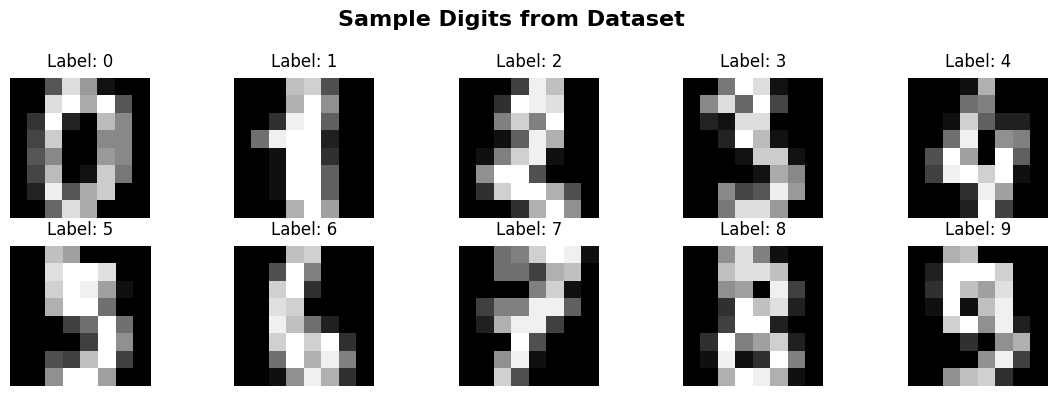

In [90]:
# Answer here for Q3

# Creating the figure
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 4)) #Figuize size is adjusted to make it wider and more spacious

# Adding the Main Title (adjust 'y' to move it up or down)
plt.suptitle("Sample Digits from Dataset", fontsize=16, fontweight='bold', y=1.05) #Y value is adjusted to move the title up



for i, ax in enumerate(axes.flat):
    # Use cmap=plt.cm.gray for white digits on black background
    ax.imshow(digits.images[i], cmap=plt.cm.gray, interpolation='nearest')

    # Adding individual labels for each digit
    ax.set_title(f"Label: {digits.target[i]}", pad=8)
    ax.axis('off')

plt.show()

In [91]:
# Q4: Split Data into Training and Testing Sets with 80% and 20% for training and testing respecively  - 1 point

# Answer here for Q4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train.shape, X_test.shape

((1437, 64), (360, 64))

In [13]:
#Q5: Train a Decision Tree Classifier  - 2 points
# Train a DecisionTreeClassifier using GridSearchCV to find the BEST model
# with highest accuracy, precision, and recall:
# Cv count is 5 and tune the parameters of model differently to see different results.

# PS. Must explain how GridSearchCV work and how paramter play a role in the training process in the class, will ask randomly

In [116]:
# Answer here for Q5

param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

dt_clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt_clf, param_grid=param_grid, cv=5, scoring='f1_macro', verbose=1)


#Fitting the model
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
print(f"BEST PARAMETERS FOUND:\nMax Depth: {grid_search.best_params_['max_depth']}")
print(f"Min Samples Split: {grid_search.best_params_['min_samples_split']}")
print(f"Min Samples Leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"\nBest Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
BEST PARAMETERS FOUND:
Max Depth: 15
Min Samples Split: 2
Min Samples Leaf: 1

Best Cross-Validation F1 Score: 0.8508


In [16]:
# Q6: Show training results  - 1 point
# Calculate training metrics

# Get best model

In [94]:
# Answer here for Q6

y_train_pred = best_model.predict(X_train)

print("TRAINING SET METRICS:")
print(f"Accuracy:  {metrics.accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"Recall:    {metrics.recall_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"F1-Score:  {metrics.f1_score(y_train, y_train_pred, average='macro'):.4f}")

TRAINING SET METRICS:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


In [19]:
# Q7: Show Output Tree information - 1 point

In [95]:
# Answer Here for Q7

print("Tree Structure:")
print(f"Tree Depth: {best_model.get_depth()}")
print(f"Number of Leaves: {best_model.get_n_leaves()}")
print(f"Number of Features Used: {X.shape[1]}")

Tree Structure:
Tree Depth: 15
Number of Leaves: 145
Number of Features Used: 64


In [24]:
#Q8: save decision tree as pdf file with graphviz - 2 point

from sklearn.tree import export_graphviz
import graphviz  # !pip install graphviz -q & also need to install external exe file (choose corresponding installer depending on your os  https://graphviz.org/download/)

In [96]:
#!pip install pydotplus
!pip install pydotplus

In [97]:
from sklearn.tree import export_graphviz
import graphviz
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"  # it might need or might not need depending on your device's configuration

# Answer Here for Q8
dot_data = export_graphviz(best_model, out_file=None,
                           feature_names=[f"Pixel_{i}" for i in range(64)],
                           class_names=[str(i) for i in range(10)],
                           filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)


In [98]:
# must save tree output as pdf file and submit together with your code file

graph.render('digit_tree', format='pdf', cleanup=True)
print("Tree structure saved and displayed!")

Tree structure saved and displayed!


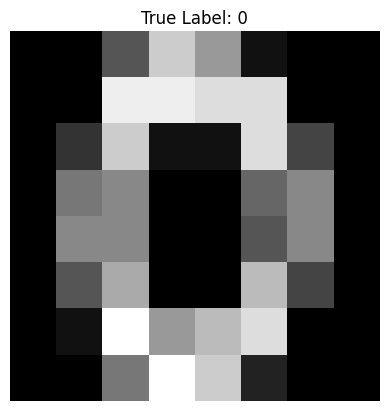

In [99]:
# Q9: Get random image from dataset and show its picture and label  - 1 point
idx = np.random.randint(0, len(X))

# Answer Here for Q9


import random
idx = random.randint(0, len(X_test)-1)
random_digit_image = X_test[idx].reshape(8, 8)
random_digit_label = y_test[idx]

plt.imshow(random_digit_image, cmap=plt.cm.gray)
plt.title(f"True Label: {random_digit_label}")
plt.axis('off')

plt.show()

In [100]:
#Q10:  Inference that image see what the model predict  - 1point


# Fill here for Q10

# 1. Getting the prediction
prediction = best_model.predict(X_test[idx].reshape(1, -1))[0]

# 2. Getting the ground truth from the test labels using the same index
true_label = y_test[idx]

print(f"Predicted label {prediction} when the ground truth is {true_label}")

Predicted label 0 when the ground truth is 0


In [101]:
pip install pillow

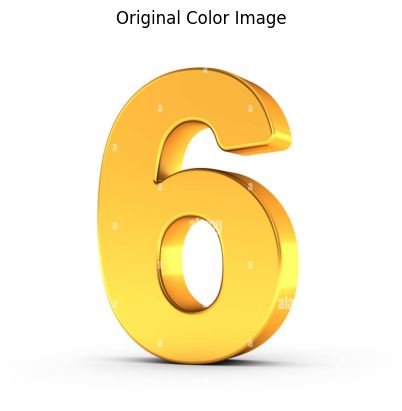

In [102]:
# Q11: Inference the new image downloaded from google.com randomly  # you can use any image you downloded from google
## show original image - 1 point


from PIL import Image # pip install pillow

#Fill here for Q11.1
from PIL import Image
import numpy as np

# Load and preprocess the image
img = Image.open('/content/Six_ML_DT_JPEG.jpg')

plt.imshow(img)
plt.title("Original Color Image")
plt.axis("off")
plt.show()

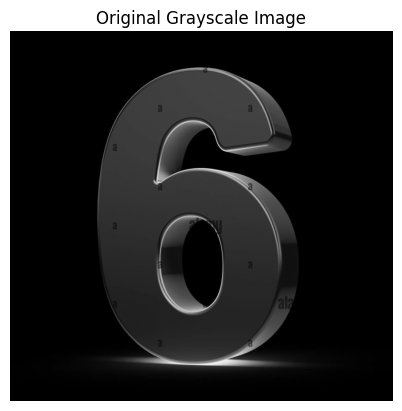

In [103]:
# Convert to gray
## show gray image - 0.5 point

#Fill here for Q11.2
img_grey = img.convert('L')
plt.imshow(img_grey, cmap='gray_r')

plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


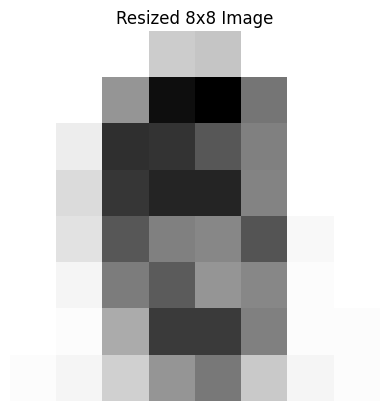

In [104]:
## show resize image - 0.5 point

#Fill here for Q11.3
img_resized_grey = img.convert('L').resize((8, 8))
plt.imshow(img_resized_grey, cmap='gray')

plt.title("Resized 8x8 Image")
plt.axis("off")
plt.show()


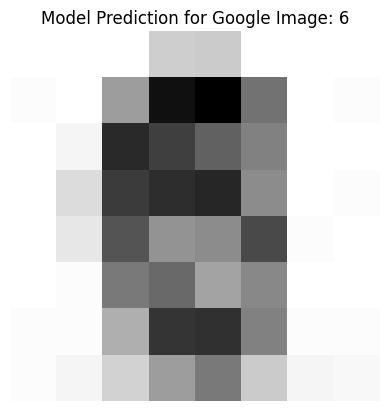

Predicted digit: 6


In [115]:
# Prediciton to the new image - 1 point
# Convert to numpy array


#Fill here for Q11.4


from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your downloaded image (ensure the file name matches)
# Let's assume you named it 'my_digit.png'
img = Image.open('/content/Six_ML_DT_JPEG.jpg').convert('L')

# 2. Preprocess: Resize to 8x8 to match the training data
img_resized = img.resize((8, 8), Image.Resampling.LANCZOS)

# 3. Converting to array and scale values
# sklearn digits are 0-16 (0=white/background, 16=black/ink)
img_array = np.array(img_resized)
img_normalized = 16.0 - (img_array / 600.0 * 16.0)

# 4. Flatten for the model
new_data = img_normalized.flatten().reshape(1, -1)

# 5. Making a Prediction
prediction = best_model.predict(new_data)[0]

# 6. Visualization with White Background
plt.imshow(img_normalized, cmap='gray_r')
plt.axis('off')
plt.title(f"Model Prediction for Google Image: {prediction}")
plt.show()


print("Predicted digit:", prediction)

In [ ]:
# marking - total 15 point

# Q1: Import Required Dependencies - 1 point
# Q2:  CHALLENGE 2: Load the Digits Dataset  - 1 point
# Q3: Visualize Sample Digits   - 1 point
# Q4: Split Data into Training and Testing Sets with 80% and 20% for training and testing respectively  - 1 point
# Q5: Train a Decision Tree Classifier  - 2 points
# Q6: Show training results  - 1 point
# Q7: Show Output Tree information - 1 point
# Q8: save decision tree as pdf file with graphviz - 2 point
# Q9: Get random image from dataset and show its picture and label  - 1 point
# Q10:  Inference that image see what the model predict  - 1point
# Q11: Infernece the new image from Google random image - 3 point